In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# =============================================================================
# 1. DIRECTORIES & DATA LOADING
# =============================================================================
project_root = os.path.expanduser('~/work/projects/summer26-permian-flaring')
interim_dir = os.path.join(project_root, 'data/interim/new-mexico')

print("Loading Datasets from Interim Directory...")
df_prodn = pd.read_csv(os.path.join(interim_dir, 'nm_wcproduction_filtered.csv'))
df_wells_og = pd.read_csv(os.path.join(interim_dir, 'nm_wells.csv'))
df_waste = pd.read_csv(os.path.join(interim_dir, 'nm_upstream_waste_nonzero.csv'))
df_mapping = pd.read_csv(os.path.join(interim_dir, 'nm_wells_to_eog_sites.csv'))

# Load the NEW VIIRS dataset with specific cloud mask columns
viirs_cols = [
    'flare_id', 'year', 'month', 
    'n_detect_cm0', 'n_nondet_cm0', 'n_detect_cm1', 'n_nondet_cm1',
    'rh_sum_cm0', 'rh_sum_cm1'
]
df_viirs_raw = pd.read_csv(os.path.join(interim_dir, 'combined_output_with_cloud_mask.csv'), usecols=viirs_cols)


# =============================================================================
# 2. GEOGRAPHIC & SITE-SPECIFIC FILTERING
# =============================================================================
lat_min, lat_max = 29.462935, 34.021515
lon_min, lon_max = -105.21988, -100.036107
min_year = 2013

# 1. Restrict to wells inside the Permian coordinates AND that are Oil Wells ('O')
df_wells_filtered = df_wells_og[
    (df_wells_og['Latitude'] >= lat_min) & (df_wells_og['Latitude'] <= lat_max) &
    (df_wells_og['Longitude'] >= lon_min) & (df_wells_og['Longitude'] <= lon_max) &
    (df_wells_og['Well_Type'] == 'O')
].copy()

df_map_subset = df_mapping[['API_Number', 'EOG_Site_ID']]

# 2. Keep ONLY the oil wells that are actively mapped to a VIIRS site (Inner Join)
df_target_wells = pd.merge(df_wells_filtered, df_map_subset, on='API_Number', how='inner')
valid_apis = df_target_wells['API_Number'].unique()
valid_sites = df_target_wells['EOG_Site_ID'].unique()

print(f"Tracking {len(valid_apis)} Oil Wells across {len(valid_sites)} VIIRS Sites.")

# 3. Filter Production Data: Only target APIs, only target years
df_prodn_filtered = df_prodn[
    (df_prodn['Year'] >= min_year) & 
    (df_prodn['API_Number'].isin(valid_apis))
]
df_oil_safe = pd.merge(df_prodn_filtered, df_map_subset, on='API_Number', how='inner')

# 4. Filter VIIRS Data: Only target years, and ONLY sites that contain our target oil wells
df_viirs_filtered = df_viirs_raw.rename(columns={'flare_id': 'EOG_Site_ID', 'year': 'Year', 'month': 'Month'})
df_viirs_filtered = df_viirs_filtered[
    (df_viirs_filtered['Year'] >= min_year) & 
    (df_viirs_filtered['EOG_Site_ID'].isin(valid_sites))
].copy()

Loading Datasets from Interim Directory...
Tracking 17250 Oil Wells across 546 VIIRS Sites.


In [2]:
# =============================================================================
# 3. FEATURE ENGINEERING, DATE FILTERING, & IMPUTATION
# =============================================================================

# -- VIIRS Aggregation --
df_viirs_filtered['total_obs'] = (
    df_viirs_filtered['n_detect_cm0'] + df_viirs_filtered['n_nondet_cm0'] +
    df_viirs_filtered['n_detect_cm1'] + df_viirs_filtered['n_nondet_cm1']
)
df_viirs_filtered['total_detects'] = (
    df_viirs_filtered['n_detect_cm0'] + df_viirs_filtered['n_detect_cm1']
)
df_viirs_filtered['total_rh'] = (
    df_viirs_filtered['rh_sum_cm0'] + df_viirs_filtered['rh_sum_cm1']
)

# Group by Year and Month
viirs_ts = df_viirs_filtered.groupby(['Year', 'Month'])[['total_obs', 'total_detects', 'total_rh']].sum().reset_index()

# Engineer the normalized features
viirs_ts['mean_rh_clear'] = viirs_ts['total_rh'] / viirs_ts['total_obs']
viirs_ts['detect_freq_clear'] = viirs_ts['total_detects'] / viirs_ts['total_obs']

# -- Oil Production Aggregation --
prod_col = 'Volume' 
oil_ts = df_oil_safe.groupby(['Year', 'Month'])[prod_col].sum().reset_index()

# -- Merge into Final Time Series --
df_ts = pd.merge(oil_ts, viirs_ts, on=['Year', 'Month'], how='inner')

# Set a proper Datetime index
df_ts['Date'] = pd.to_datetime(df_ts[['Year', 'Month']].assign(DAY=1))
df_ts.set_index('Date', inplace=True)
df_ts.sort_index(inplace=True)

# ---------------------------------------------------------
# NEW: Date Restriction & Data Imputation
# ---------------------------------------------------------

# 1. Restrict data to end in January 2026
df_ts = df_ts.loc[:'2026-01-01']

# 2. Handle the corrupted VIIRS data in August 2022
corrupted_date = '2022-08-01'

if corrupted_date in df_ts.index:
    print(f"Nulling corrupted VIIRS data for {corrupted_date}...")
    # Set ONLY the VIIRS columns to NaN for this specific month
    viirs_cols = ['total_obs', 'total_detects', 'total_rh', 'mean_rh_clear', 'detect_freq_clear']
    df_ts.loc[corrupted_date, viirs_cols] = np.nan
    
    # 3. Interpolate the missing values
    # We use 'time' method which behaves linearly but respects the actual days between index points
    df_ts[viirs_cols] = df_ts[viirs_cols].interpolate(method='time')
    print("August 2022 data successfully interpolated.")

print(f"\nFinal Time Series range: {df_ts.index.min().date()} to {df_ts.index.max().date()}")
print("Time Series shape:", df_ts.shape)
display(df_ts.head())

Nulling corrupted VIIRS data for 2022-08-01...
August 2022 data successfully interpolated.

Final Time Series range: 2013-01-01 to 2026-01-01
Time Series shape: (157, 8)


,Year,Month,Volume,total_obs,total_detects,total_rh,mean_rh_clear,detect_freq_clear
Date,,,,,,,,
2013-01-01,2013,1,10196367,16132.0,222.0,552.972794,0.034278,0.013761
2013-02-01,2013,2,9740947,16493.0,171.0,306.208861,0.018566,0.010368
2013-03-01,2013,3,11134433,17847.0,272.0,381.070971,0.021352,0.015241
2013-04-01,2013,4,11897117,16765.0,145.0,164.458560,0.009810,0.008649
2013-05-01,2013,5,12194822,16174.0,238.0,483.677959,0.029905,0.014715


In [5]:
df_ts.tail(20)

,Year,Month,Volume,total_obs,total_detects,total_rh,mean_rh_clear,detect_freq_clear
Date,,,,,,,,
2024-06-01,2024,6,107693092,17050.0,513.0,342.389501,0.020081,0.030088
2024-07-01,2024,7,115383575,7823.0,582.0,442.462292,0.056559,0.074396
2024-08-01,2024,8,117265668,20037.0,1016.0,918.856850,0.045858,0.050706
2024-09-01,2024,9,109224390,18013.0,739.0,599.280068,0.033269,0.041026
2024-10-01,2024,10,117368547,24497.0,963.0,850.334750,0.034712,0.039311
2024-11-01,2024,11,114014517,13947.0,639.0,498.138001,0.035716,0.045816
2024-12-01,2024,12,117935367,19947.0,967.0,728.089916,0.036501,0.048478
2025-01-01,2025,1,112362457,18179.0,1111.0,1024.259864,0.056343,0.061114
2025-02-01,2025,2,110235105,19001.0,1268.0,1029.817999,0.054198,0.066733


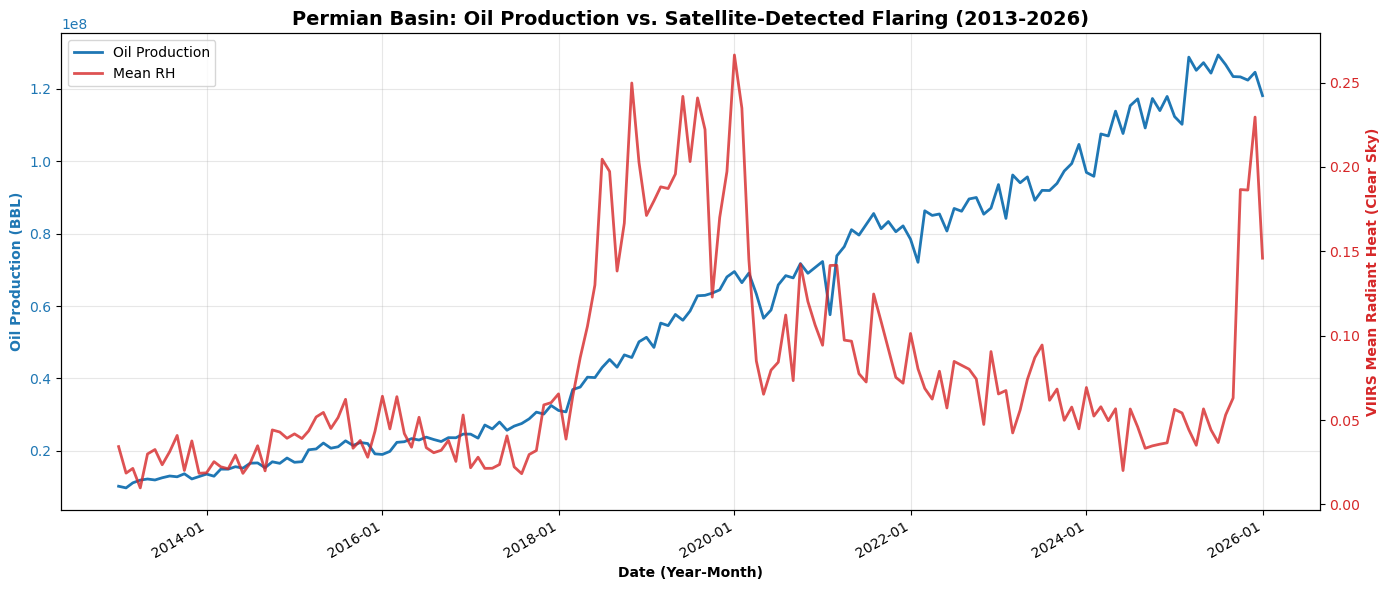

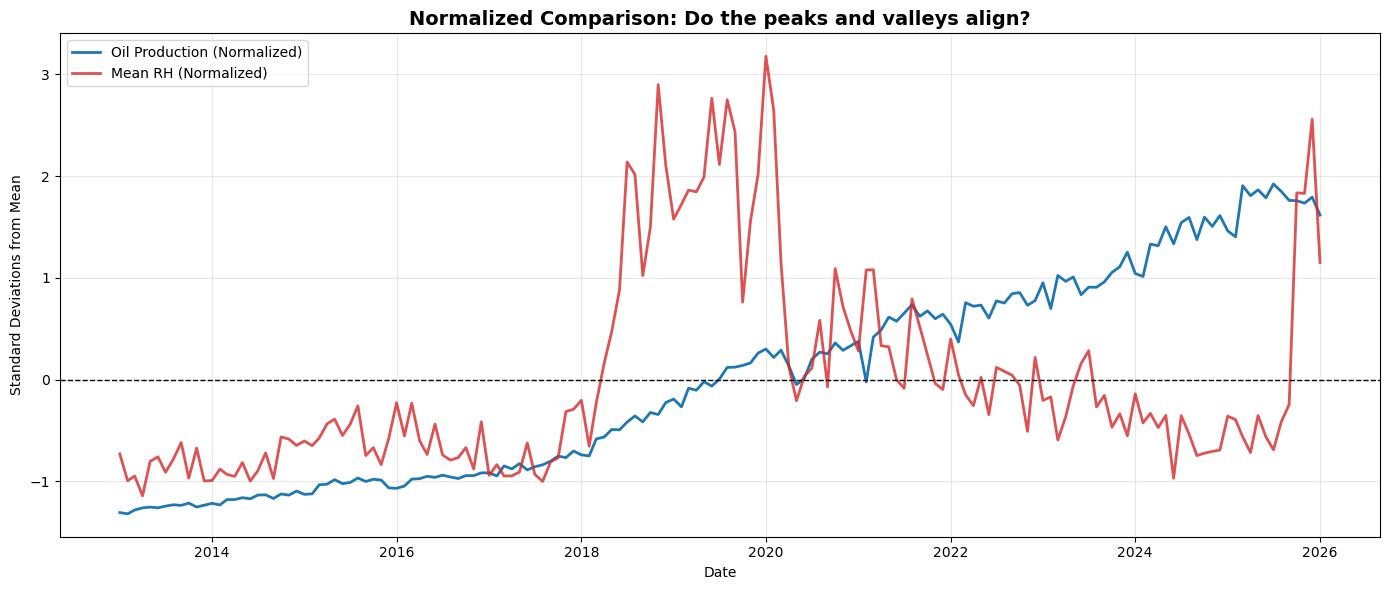

In [6]:
# =============================================================================
# 3.5. VISUAL EXPLORATION: PLOTTING THE TIME SERIES
# =============================================================================
from sklearn.preprocessing import StandardScaler

prod_col = 'Volume'
exo_feature = 'mean_rh_clear'

# --- Plot 1: Dual Y-Axis Plot (Actual Values) ---
fig, ax1 = plt.subplots(figsize=(14, 6))

color1 = 'tab:blue'
ax1.set_xlabel('Date (Year-Month)', fontweight='bold')
ax1.set_ylabel('Oil Production (BBL)', color=color1, fontweight='bold')
# Plot Oil Production
line1 = ax1.plot(df_ts.index, df_ts[prod_col], color=color1, linewidth=2, label='Oil Production')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, alpha=0.3)

# Create a second y-axis that shares the same x-axis
ax2 = ax1.twinx()  
color2 = 'tab:red'
ax2.set_ylabel('VIIRS Mean Radiant Heat (Clear Sky)', color=color2, fontweight='bold')
# Plot VIIRS Data
line2 = ax2.plot(df_ts.index, df_ts[exo_feature], color=color2, linewidth=2, alpha=0.8, label='Mean RH')
ax2.tick_params(axis='y', labelcolor=color2)

# Combine legends from both axes
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.title('Permian Basin: Oil Production vs. Satellite-Detected Flaring (2013-2026)', fontsize=14, fontweight='bold')
# Format the x-axis dates nicely
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


# --- Plot 2: Normalized Overlay (Z-Scores) ---
# This forces both series to have a mean of 0 and std dev of 1, 
# making it incredibly easy to see if the peaks and valleys align.
scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_ts[[prod_col, exo_feature]]), 
    columns=[f'{prod_col}_scaled', f'{exo_feature}_scaled'], 
    index=df_ts.index
)

plt.figure(figsize=(14, 6))
plt.plot(df_scaled.index, df_scaled[f'{prod_col}_scaled'], color='tab:blue', linewidth=2, label='Oil Production (Normalized)')
plt.plot(df_scaled.index, df_scaled[f'{exo_feature}_scaled'], color='tab:red', linewidth=2, alpha=0.8, label='Mean RH (Normalized)')

plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.title('Normalized Comparison: Do the peaks and valleys align?', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Standard Deviations from Mean')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

--------------------------------------------------
1. STATIONARITY CHECKS (Augmented Dickey-Fuller)
--------------------------------------------------
[Raw Oil Volume] ADF p-value: 0.9753
  -> NOT Stationary (Needs differencing, d=1).
[Raw VIIRS Mean RH] ADF p-value: 0.3404
  -> NOT Stationary (Needs differencing, d=1).

(Checking differenced data...)
[Differenced Oil Volume] ADF p-value: 0.0698
  -> NOT Stationary (Needs differencing, d=1).
[Differenced VIIRS Mean RH] ADF p-value: 0.0000
  -> Stationary (d=0).

--------------------------------------------------
2. GRANGER CAUSALITY TEST
--------------------------------------------------
H0: Past VIIRS values do NOT help forecast Oil Volume.

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.0016  , p=0.9682  , df_denom=152, df_num=1
ssr based chi2 test:   chi2=0.0016  , p=0.9679  , df=1
likelihood ratio test: chi2=0.0016  , p=0.9679  , df=1
parameter F test:         F=0.0016  , p=0.9682  , df_denom=152, df_num

/Users/vineeth/work/conda_env/envs/summer26-permian-flaring/lib/python3.14/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


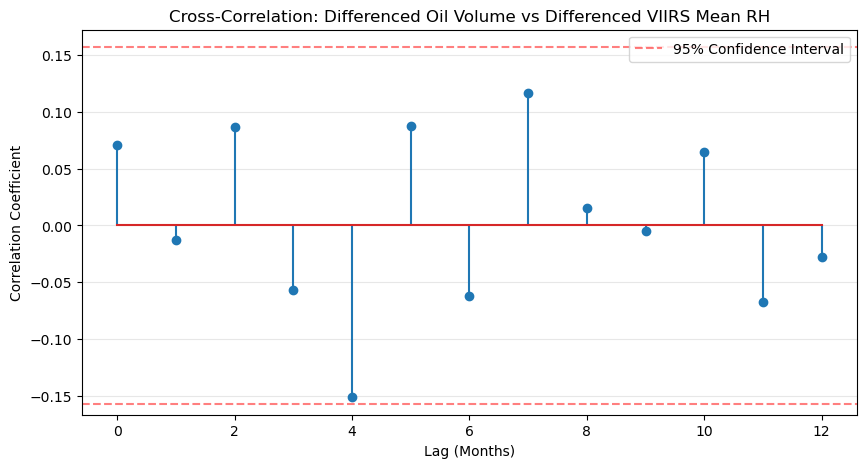

In [15]:
# =============================================================================
# 4. STATISTICAL VALIDATION FOR ARIMAX
# =============================================================================
from statsmodels.tsa.stattools import adfuller, grangercausalitytests, ccf

target = prod_col  # 'Volume'

print("--------------------------------------------------")
print("1. STATIONARITY CHECKS (Augmented Dickey-Fuller)")
print("--------------------------------------------------")
def adf_test(series, name):
    result = adfuller(series.dropna())
    p_value = result[1]
    
    print(f"[{name}] ADF p-value: {p_value:.4f}")
    if p_value < 0.05:
        print(f"  -> Stationary (d=0).")
    else:
        print(f"  -> NOT Stationary (Needs differencing, d=1).")
    return p_value

# Check the raw series
p_target = adf_test(df_ts[target], "Raw Oil Volume")
p_exo = adf_test(df_ts[exo_feature], "Raw VIIRS Mean RH")

# Difference the data to make it stationary for modeling tests
df_diff = df_ts.diff().dropna()

print("\n(Checking differenced data...)")
adf_test(df_diff[target], "Differenced Oil Volume")
adf_test(df_diff[exo_feature], "Differenced VIIRS Mean RH")


print("\n--------------------------------------------------")
print("2. GRANGER CAUSALITY TEST")
print("--------------------------------------------------")
print(f"H0: Past VIIRS values do NOT help forecast Oil Volume.")

# Testing up to 4 months of lags on the stationary series
try:
    gc_res = grangercausalitytests(df_diff[[target, exo_feature]], maxlag=4, verbose=True)
except Exception as e:
    print(f"Error running Granger test: {e}")


print("\n--------------------------------------------------")
print("3. CROSS-CORRELATION FUNCTION (CCF)")
print("--------------------------------------------------")
ccf_vals = ccf(df_diff[target], df_diff[exo_feature], adjusted=False)

plt.figure(figsize=(10, 5))
lags_to_plot = 12
plt.stem(range(lags_to_plot + 1), ccf_vals[:lags_to_plot + 1]) 

conf_int = 1.96 / np.sqrt(len(df_diff))
plt.axhline(conf_int, color='red', linestyle='--', alpha=0.5, label='95% Confidence Interval')
plt.axhline(-conf_int, color='red', linestyle='--', alpha=0.5)

plt.title('Cross-Correlation: Differenced Oil Volume vs Differenced VIIRS Mean RH')
plt.xlabel('Lag (Months)')
plt.ylabel('Correlation Coefficient')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

Training on 76 months: 2013-01-01 to 2019-04-01
Testing on 20 months: 2019-05-01 to 2020-12-01

Scaling exogenous variables to stabilize the solver...

Running Auto-ARIMA grid search on scaled data...
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   76
Model:               SARIMAX(3, 1, 1)   Log Likelihood                -135.583
Date:                Sat, 04 Jul 2026   AIC                            285.166
Time:                        23:32:16   BIC                            301.389
Sample:                    01-01-2013   HQIC                           291.644
                         - 04-01-2019                                         
Covariance Type:                  opg                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
int

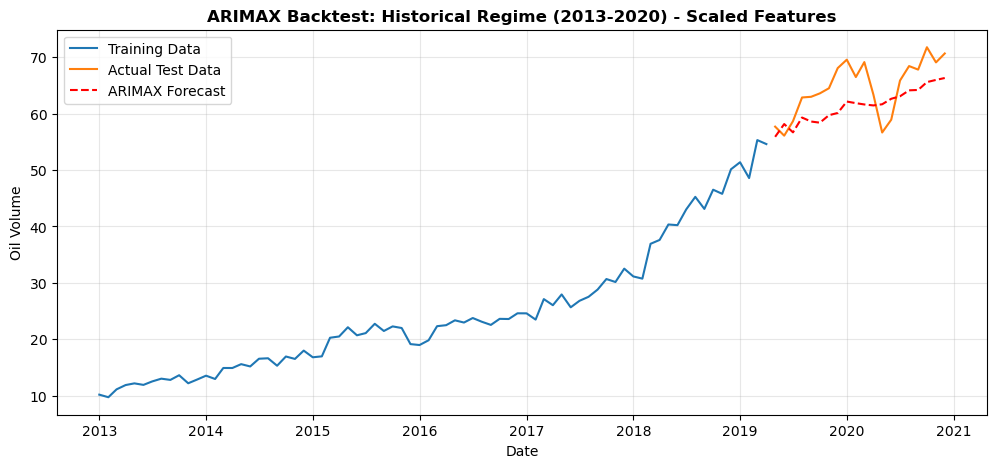

In [ ]:
# =============================================================================
# 5. HISTORICAL BACKTEST (2013 - 2020) WITH SCALED FEATURES
# =============================================================================
import pmdarima as pm
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

# Convert Oil Volume to Millions of Barrels to stabilize the model variance
df_ts['Volume_MMbbl'] = df_ts['Volume'] / 1e6

# 1. Isolate the Historical Regime (2013 through 2020)
df_history = df_ts.loc[:'2020-12-01'].copy()

# 2. Sequential Train-Test Split (80/20)
split_idx = int(len(df_history) * 0.8)
train = df_history.iloc[:split_idx]
test = df_history.iloc[split_idx:]

target_col = 'Volume_MMbbl'
exo_cols = ['mean_rh_clear']

print(f"Training on {len(train)} months: {train.index.min().date()} to {train.index.max().date()}")
print(f"Testing on {len(test)} months: {test.index.min().date()} to {test.index.max().date()}")

# ---------------------------------------------------------
# Feature Scaling (Fixing the Condition Number Warning)
# ---------------------------------------------------------
print("\nScaling exogenous variables to stabilize the solver...")
scaler = StandardScaler()

# Fit the scaler ONLY on the training data to prevent data leakage, then transform
train_exo_scaled = pd.DataFrame(
    scaler.fit_transform(train[exo_cols]), 
    columns=exo_cols, 
    index=train.index
)

# Transform the test data using the SAME scaler fitted on the training data
test_exo_scaled = pd.DataFrame(
    scaler.transform(test[exo_cols]), 
    columns=exo_cols, 
    index=test.index
)

# 3. Fit the ARIMAX Model using Auto-ARIMA
print("\nRunning Auto-ARIMA grid search on scaled data...")
model = pm.auto_arima(
    y=train[target_col], 
    X=train_exo_scaled,  # Pass the SCALED training features here
    start_p=0, start_q=0,
    max_p=3, max_q=3,
    d=None, # Let the algorithm determine 'd' via ADF tests
    seasonal=False,
    stepwise=True,
    suppress_warnings=True,
    error_action="ignore"
)
print(model.summary())

# 4. Forecast the Test Set
# Pass the SCALED test features here
predictions = model.predict(n_periods=len(test), X=test_exo_scaled)
test_with_preds = test.copy()
test_with_preds['Forecast'] = predictions

# 5. Evaluate and Plot
mape = mean_absolute_percentage_error(test_with_preds[target_col], test_with_preds['Forecast'])
print(f"\nMean Absolute Percentage Error (MAPE): {mape:.2%}")

plt.figure(figsize=(12, 5))
plt.plot(train.index, train[target_col], label='Training Data')
plt.plot(test_with_preds.index, test_with_preds[target_col], label='Actual Test Data')
plt.plot(test_with_preds.index, test_with_preds['Forecast'], color='red', linestyle='--', label='ARIMAX Forecast')
plt.title('ARIMAX Backtest: Historical Regime (2013-2020) - Scaled Features', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Oil Volume')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Training on 76 months: 2013-01-01 to 2019-04-01
Testing on 20 months: 2019-05-01 to 2020-12-01

Scaling exogenous variables...

Running Auto-ARIMA grid search (Optimizing for BIC)...
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   76
Model:               SARIMAX(0, 1, 1)   Log Likelihood                 106.482
Date:                Sat, 04 Jul 2026   AIC                           -204.963
Time:                        23:32:26   BIC                           -195.693
Sample:                    01-01-2013   HQIC                          -201.262
                         - 04-01-2019                                         
Covariance Type:                  opg                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
intercept         0.0

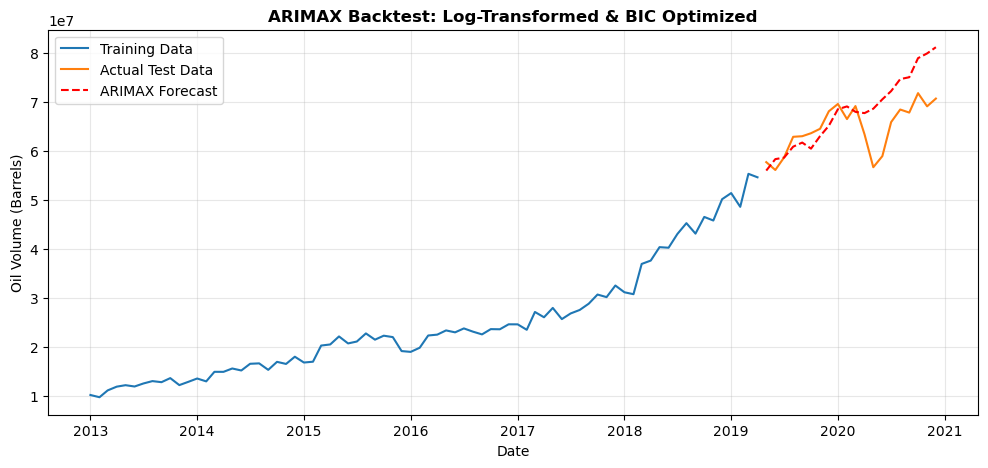

In [23]:
# =============================================================================
# 5. HISTORICAL BACKTEST (2013 - 2020) WITH LOG TRANSFORM & BIC PENALTY
# =============================================================================
import pmdarima as pm
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
import numpy as np

# 1. Isolate the Historical Regime (2013 through 2020)
df_history = df_ts.loc[:'2020-12-01'].copy()

# -- NEW: Log Transformation --
# We take the natural log of the raw Volume to stabilize the exponential growth and variance
df_history['Log_Volume'] = np.log(df_history['Volume'])

# 2. Sequential Train-Test Split (80/20)
split_idx = int(len(df_history) * 0.8)
train = df_history.iloc[:split_idx]
test = df_history.iloc[split_idx:]

# Target is now the Log-transformed volume
target_col = 'Log_Volume'
exo_cols = ['mean_rh_clear']

print(f"Training on {len(train)} months: {train.index.min().date()} to {train.index.max().date()}")
print(f"Testing on {len(test)} months: {test.index.min().date()} to {test.index.max().date()}")

# 3. Feature Scaling for Exogenous Variables
print("\nScaling exogenous variables...")
scaler = StandardScaler()
train_exo_scaled = pd.DataFrame(
    scaler.fit_transform(train[exo_cols]), 
    columns=exo_cols, 
    index=train.index
)
test_exo_scaled = pd.DataFrame(
    scaler.transform(test[exo_cols]), 
    columns=exo_cols, 
    index=test.index
)

# 4. Fit the ARIMAX Model using Auto-ARIMA
# -- NEW: Set information_criterion to 'bic' to strongly penalize complex models --
print("\nRunning Auto-ARIMA grid search (Optimizing for BIC)...")
model = pm.auto_arima(
    y=train[target_col], 
    X=train_exo_scaled,
    start_p=0, start_q=0,
    max_p=3, max_q=3,
    d=None, 
    seasonal=False,
    information_criterion='bic',  # Forces the solver to prefer simpler models
    stepwise=True,
    suppress_warnings=True,
    error_action="ignore"
)
print(model.summary())

# 5. Forecast the Test Set
log_predictions = model.predict(n_periods=len(test), X=test_exo_scaled)
test_with_preds = test.copy()

# -- NEW: Inverse the Log Transform --
# We use np.exp() to convert the log forecast back into standard Barrels
test_with_preds['Forecast_Volume'] = np.exp(log_predictions)
test_with_preds['Actual_Volume'] = test['Volume'] 

# 6. Evaluate and Plot on the original scale
mape = mean_absolute_percentage_error(test_with_preds['Actual_Volume'], test_with_preds['Forecast_Volume'])
print(f"\nMean Absolute Percentage Error (MAPE) on actual volume: {mape:.2%}")

plt.figure(figsize=(12, 5))
plt.plot(train.index, train['Volume'], label='Training Data')
plt.plot(test_with_preds.index, test_with_preds['Actual_Volume'], label='Actual Test Data')
plt.plot(test_with_preds.index, test_with_preds['Forecast_Volume'], color='red', linestyle='--', label='ARIMAX Forecast')
plt.title('ARIMAX Backtest: Log-Transformed & BIC Optimized', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Oil Volume (Barrels)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Training on 76 months: 2013-01-01 to 2019-04-01
Testing on 20 months: 2019-05-01 to 2020-12-01

Scaling exogenous variables...

Running Auto-ARIMA grid search (Optimizing for BIC)...
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   76
Model:               SARIMAX(0, 1, 1)   Log Likelihood                 107.543
Date:                Sat, 04 Jul 2026   AIC                           -207.085
Time:                        23:47:00   BIC                           -197.815
Sample:                    01-01-2013   HQIC                          -203.384
                         - 04-01-2019                                         
Covariance Type:                  opg                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
intercept    

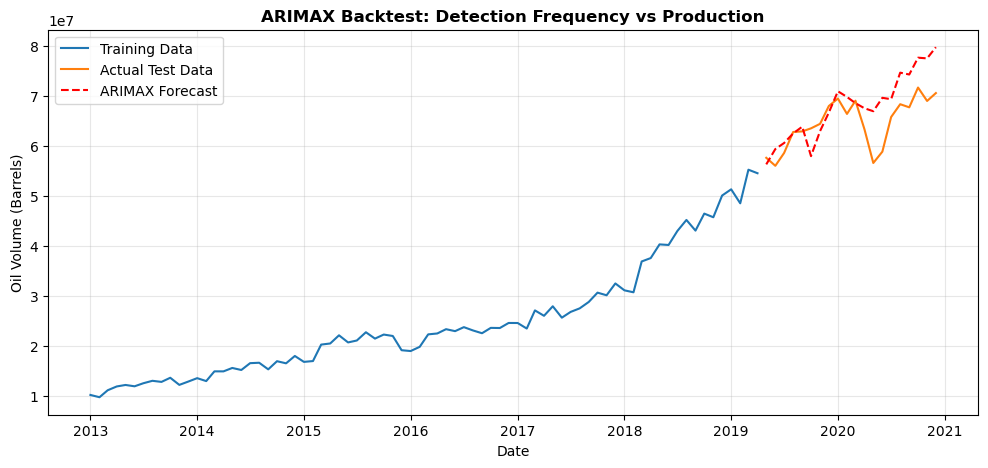

In [28]:
# =============================================================================
# 5. HISTORICAL BACKTEST: TESTING FLARING FREQUENCY
# =============================================================================
import pmdarima as pm
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
import numpy as np

# 1. Isolate the Historical Regime (2013 through 2020)
df_history = df_ts.loc[:'2020-12-01'].copy()

# Log Transformation
df_history['Log_Volume'] = np.log(df_history['Volume'])

# 2. Sequential Train-Test Split (80/20)
split_idx = int(len(df_history) * 0.8)
train = df_history.iloc[:split_idx]
test = df_history.iloc[split_idx:]

target_col = 'Log_Volume'
# -- CHANGED: Swapping intensity for frequency --
exo_cols = ['detect_freq_clear'] 

print(f"Training on {len(train)} months: {train.index.min().date()} to {train.index.max().date()}")
print(f"Testing on {len(test)} months: {test.index.min().date()} to {test.index.max().date()}")

# 3. Feature Scaling
print("\nScaling exogenous variables...")
scaler = StandardScaler()
train_exo_scaled = pd.DataFrame(
    scaler.fit_transform(train[exo_cols]), 
    columns=exo_cols, 
    index=train.index
)
test_exo_scaled = pd.DataFrame(
    scaler.transform(test[exo_cols]), 
    columns=exo_cols, 
    index=test.index
)

# 4. Fit the ARIMAX Model using Auto-ARIMA
print("\nRunning Auto-ARIMA grid search (Optimizing for BIC)...")
model = pm.auto_arima(
    y=train[target_col], 
    X=train_exo_scaled,
    start_p=0, start_q=0,
    max_p=3, max_q=3,
    d=None, 
    seasonal=False,
    information_criterion='bic',  
    stepwise=True,
    suppress_warnings=True,
    error_action="ignore"
)
print(model.summary())

# 5. Forecast the Test Set
log_predictions = model.predict(n_periods=len(test), X=test_exo_scaled)
test_with_preds = test.copy()

# Inverse the Log Transform
test_with_preds['Forecast_Volume'] = np.exp(log_predictions)
test_with_preds['Actual_Volume'] = test['Volume'] 

# 6. Evaluate and Plot
mape = mean_absolute_percentage_error(test_with_preds['Actual_Volume'], test_with_preds['Forecast_Volume'])
print(f"\nMean Absolute Percentage Error (MAPE) on actual volume: {mape:.2%}")

plt.figure(figsize=(12, 5))
plt.plot(train.index, train['Volume'], label='Training Data')
plt.plot(test_with_preds.index, test_with_preds['Actual_Volume'], label='Actual Test Data')
plt.plot(test_with_preds.index, test_with_preds['Forecast_Volume'], color='red', linestyle='--', label='ARIMAX Forecast')
plt.title('ARIMAX Backtest: Detection Frequency vs Production', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Oil Volume (Barrels)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [17]:
# =============================================================================
# 6. MULTICOLLINEARITY CHECK (VIF)
# =============================================================================
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Create a dataframe with just the variables we want to test
X_test = df_ts[['mean_rh_clear', 'detect_freq_clear']].dropna()

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X_test.columns
vif_data["VIF"] = [variance_inflation_factor(X_test.values, i) for i in range(len(X_test.columns))]

print(vif_data)

             Feature        VIF
0      mean_rh_clear  19.331801
1  detect_freq_clear  19.331801


Training on 48 months: 2021-01-01 to 2024-12-01
Testing on 13 months: 2025-01-01 to 2026-01-01

Scaling exogenous variables...

Running Auto-ARIMA grid search (Optimizing for BIC)...
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   48
Model:               SARIMAX(0, 1, 1)   Log Likelihood                  65.899
Date:                Sat, 04 Jul 2026   AIC                           -123.798
Time:                        23:38:10   BIC                           -116.397
Sample:                    01-01-2021   HQIC                          -121.013
                         - 12-01-2024                                         
Covariance Type:                  opg                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
intercept    

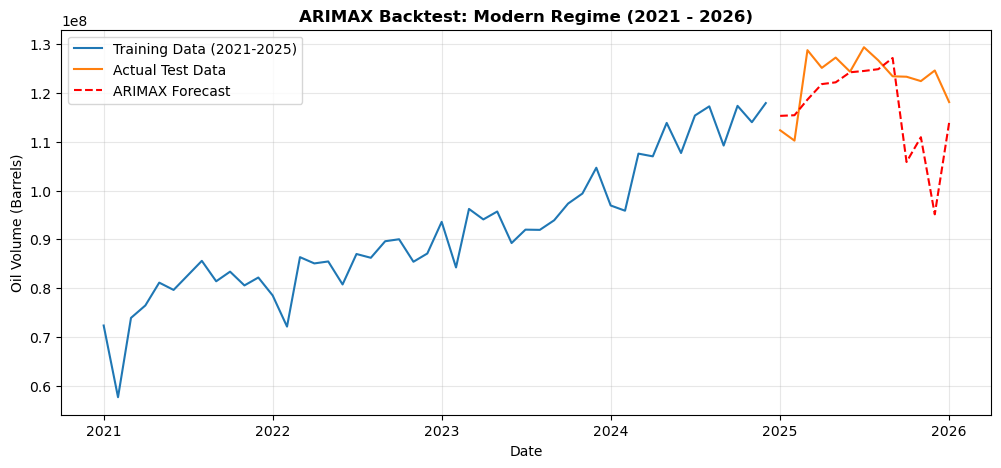

In [25]:
# =============================================================================
# 7. MODERN ERA BACKTEST (2021 - 2026): TESTING THE ESG / PIPELINE SHIFT
# =============================================================================
import pmdarima as pm
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# 1. Isolate the Modern Regime (Jan 2021 through Jan 2026)
df_modern = df_ts.loc['2021-01-01':'2026-01-01'].copy()

# Log Transformation for stable variance
df_modern['Log_Volume'] = np.log(df_modern['Volume'])

# 2. Sequential Train-Test Split (80/20)
split_idx = int(len(df_modern) * 0.8)
train = df_modern.iloc[:split_idx]
test = df_modern.iloc[split_idx:]

target_col = 'Log_Volume'
exo_cols = ['detect_freq_clear'] 

print(f"Training on {len(train)} months: {train.index.min().date()} to {train.index.max().date()}")
print(f"Testing on {len(test)} months: {test.index.min().date()} to {test.index.max().date()}")

# 3. Feature Scaling
print("\nScaling exogenous variables...")
scaler = StandardScaler()
train_exo_scaled = pd.DataFrame(
    scaler.fit_transform(train[exo_cols]), 
    columns=exo_cols, 
    index=train.index
)
test_exo_scaled = pd.DataFrame(
    scaler.transform(test[exo_cols]), 
    columns=exo_cols, 
    index=test.index
)

# 4. Fit the ARIMAX Model using Auto-ARIMA
print("\nRunning Auto-ARIMA grid search (Optimizing for BIC)...")
model = pm.auto_arima(
    y=train[target_col], 
    X=train_exo_scaled,
    start_p=0, start_q=0,
    max_p=3, max_q=3,
    d=None, 
    seasonal=False,
    information_criterion='bic',  
    stepwise=True,
    suppress_warnings=True,
    error_action="ignore"
)
print(model.summary())

# 5. Forecast the Test Set
log_predictions = model.predict(n_periods=len(test), X=test_exo_scaled)
test_with_preds = test.copy()

# Inverse the Log Transform to get real Barrels
test_with_preds['Forecast_Volume'] = np.exp(log_predictions)
test_with_preds['Actual_Volume'] = test['Volume'] 

# 6. Evaluate and Plot
mape = mean_absolute_percentage_error(test_with_preds['Actual_Volume'], test_with_preds['Forecast_Volume'])
print(f"\nMean Absolute Percentage Error (MAPE) on actual volume: {mape:.2%}")

plt.figure(figsize=(12, 5))
plt.plot(train.index, train['Volume'], label='Training Data (2021-2025)')
plt.plot(test_with_preds.index, test_with_preds['Actual_Volume'], color='tab:orange', label='Actual Test Data')
plt.plot(test_with_preds.index, test_with_preds['Forecast_Volume'], color='red', linestyle='--', label='ARIMAX Forecast')
plt.title('ARIMAX Backtest: Modern Regime (2021 - 2026)', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Oil Volume (Barrels)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

While VIIRS satellite telemetry was a highly accurate proxy for Permian oil production in the infrastructure-constrained era (2013-2020), the physical and regulatory changes in the modern era (2021-2026) have permanently decoupled flaring from production, rendering the satellite data an unreliable exogenous variable for future forecasting.


--- Training Baseline ARIMA (No Satellite Data) ---
Baseline Model Selected: (0, 1, 1)

--- Training ARIMAX (With Satellite Data) ---
ARIMAX Model Selected: (0, 1, 1)

================ PERFORMANCE SUMMARY ================
Baseline ARIMA MAPE: 10.11%
ARIMAX MAPE:         6.79%
Improvement:         3.32% absolute percentage points


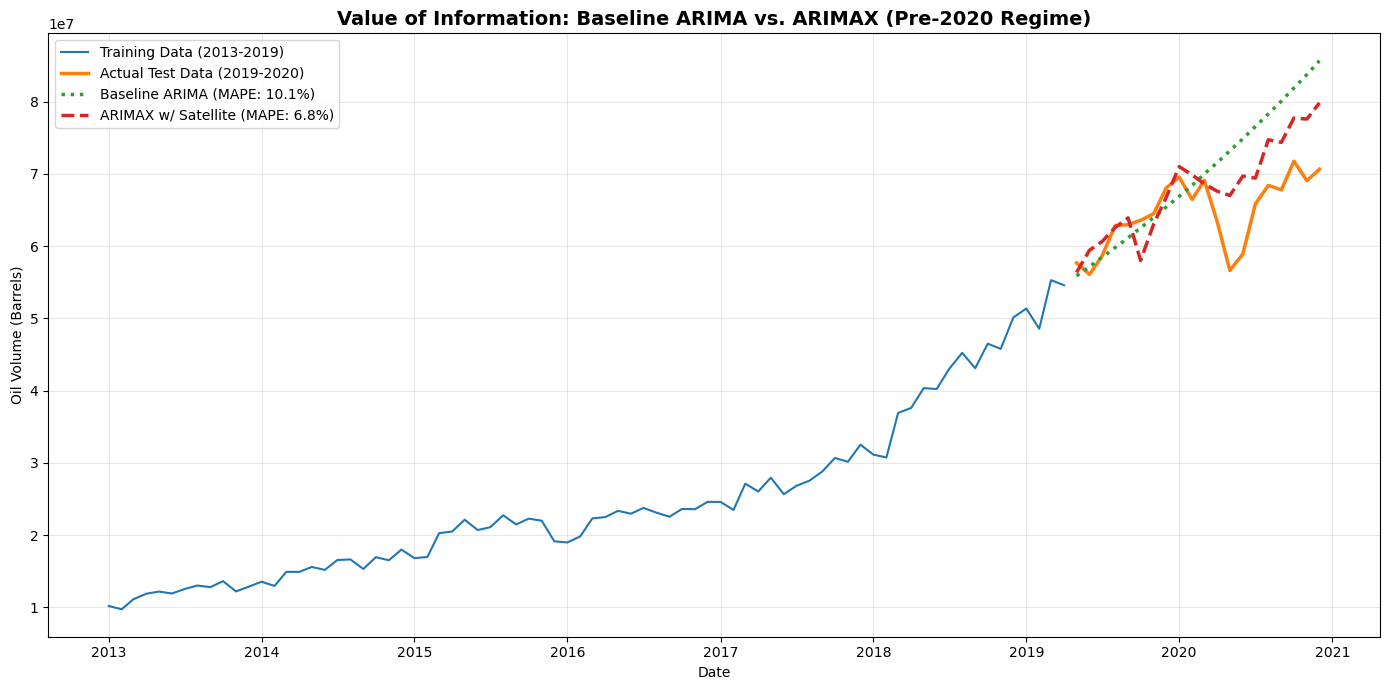

In [29]:
# =============================================================================
# 8. HEAD-TO-HEAD: BASELINE ARIMA vs. ARIMAX (Pre-2020 Regime)
# =============================================================================
import pmdarima as pm
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# 1. Isolate the Historical Regime (2013 through 2020)
df_history = df_ts.loc[:'2020-12-01'].copy()
df_history['Log_Volume'] = np.log(df_history['Volume'])

# 2. Sequential Train-Test Split (80/20)
split_idx = int(len(df_history) * 0.8)
train = df_history.iloc[:split_idx]
test = df_history.iloc[split_idx:]

target_col = 'Log_Volume'
exo_cols = ['detect_freq_clear']

# 3. Feature Scaling for ARIMAX
scaler = StandardScaler()
train_exo_scaled = pd.DataFrame(
    scaler.fit_transform(train[exo_cols]), 
    columns=exo_cols, 
    index=train.index
)
test_exo_scaled = pd.DataFrame(
    scaler.transform(test[exo_cols]), 
    columns=exo_cols, 
    index=test.index
)

# ---------------------------------------------------------
# 4. Train the Baseline Model (ARIMA - NO Exogenous Data)
# ---------------------------------------------------------
print("\n--- Training Baseline ARIMA (No Satellite Data) ---")
model_baseline = pm.auto_arima(
    y=train[target_col], 
    start_p=0, start_q=0, max_p=3, max_q=3,
    d=None, seasonal=False, information_criterion='bic', 
    stepwise=True, suppress_warnings=True, error_action="ignore"
)
print(f"Baseline Model Selected: {model_baseline.order}")

# ---------------------------------------------------------
# 5. Train the ARIMAX Model (WITH Satellite Data)
# ---------------------------------------------------------
print("\n--- Training ARIMAX (With Satellite Data) ---")
model_arimax = pm.auto_arima(
    y=train[target_col], 
    X=train_exo_scaled,
    start_p=0, start_q=0, max_p=3, max_q=3,
    d=None, seasonal=False, information_criterion='bic', 
    stepwise=True, suppress_warnings=True, error_action="ignore"
)
print(f"ARIMAX Model Selected: {model_arimax.order}")

# ---------------------------------------------------------
# 6. Generate Forecasts & Inverse Log Transform
# ---------------------------------------------------------
# Baseline prediction (requires no X)
preds_baseline_log = model_baseline.predict(n_periods=len(test))
forecast_baseline = np.exp(preds_baseline_log)

# ARIMAX prediction (requires scaled X)
preds_arimax_log = model_arimax.predict(n_periods=len(test), X=test_exo_scaled)
forecast_arimax = np.exp(preds_arimax_log)

test_actual = test['Volume']

# ---------------------------------------------------------
# 7. Evaluate Metrics
# ---------------------------------------------------------
mape_baseline = mean_absolute_percentage_error(test_actual, forecast_baseline)
mape_arimax = mean_absolute_percentage_error(test_actual, forecast_arimax)

print(f"\n================ PERFORMANCE SUMMARY ================")
print(f"Baseline ARIMA MAPE: {mape_baseline:.2%}")
print(f"ARIMAX MAPE:         {mape_arimax:.2%}")
print(f"Improvement:         {mape_baseline - mape_arimax:.2%} absolute percentage points")
print("=====================================================")

# ---------------------------------------------------------
# 8. Visual Comparison
# ---------------------------------------------------------
plt.figure(figsize=(14, 7))

# Plot historical data
plt.plot(train.index, train['Volume'], color='tab:blue', label='Training Data (2013-2019)')

# Plot actual test data
plt.plot(test.index, test_actual, color='tab:orange', linewidth=2.5, label='Actual Test Data (2019-2020)')

# Plot forecasts
plt.plot(test.index, forecast_baseline, color='tab:green', linestyle=':', linewidth=2.5, 
         label=f'Baseline ARIMA (MAPE: {mape_baseline:.1%})')
plt.plot(test.index, forecast_arimax, color='tab:red', linestyle='--', linewidth=2.5, 
         label=f'ARIMAX w/ Satellite (MAPE: {mape_arimax:.1%})')

plt.title('Value of Information: Baseline ARIMA vs. ARIMAX (Pre-2020 Regime)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Oil Volume (Barrels)')
plt.legend(loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Starting Robustness Test across multiple splits...

--- Processing 60/40 Split ---
Selected Model: (0, 1, 1)
MAPE: 25.04%

--- Processing 70/30 Split ---
Selected Model: (3, 2, 1)
MAPE: 10.38%

--- Processing 80/20 Split ---
Selected Model: (0, 1, 1)
MAPE: 6.79%



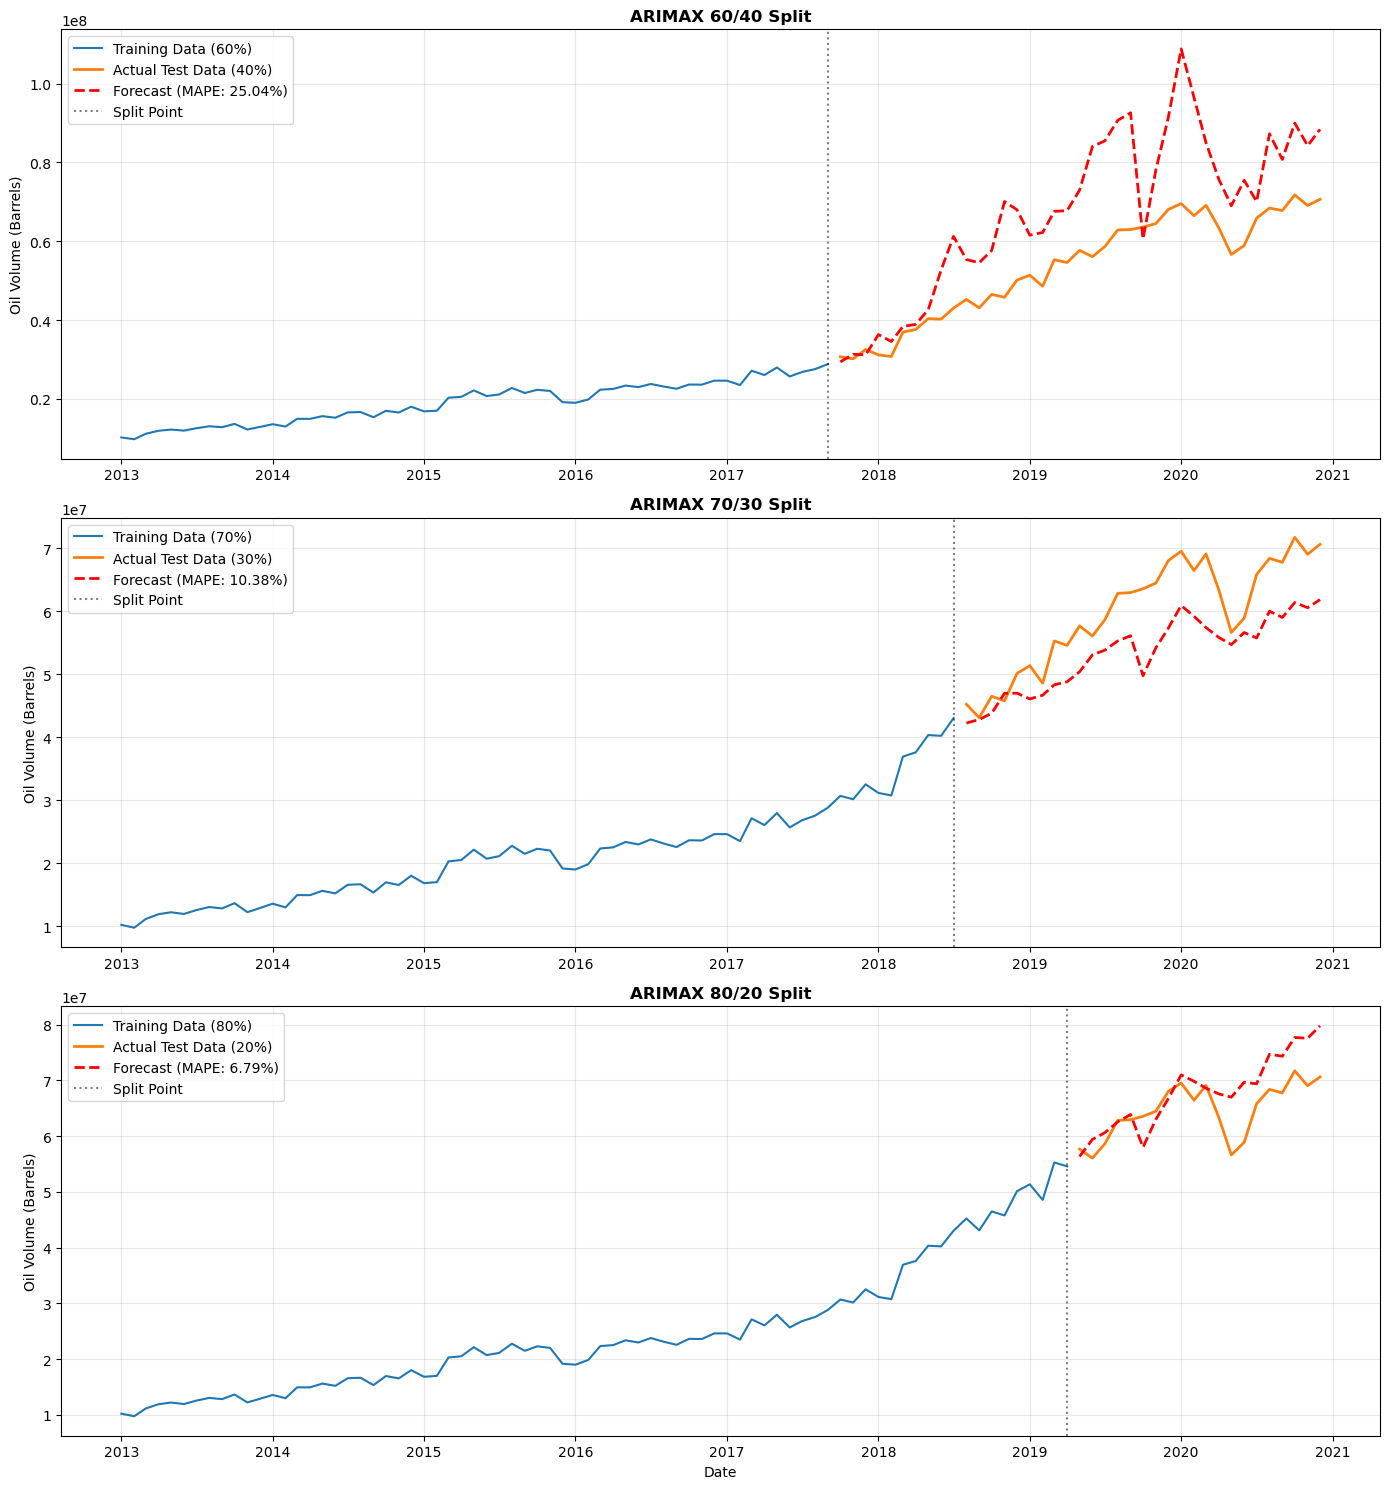

In [30]:
# =============================================================================
# 9. ROBUSTNESS TEST: MULTIPLE TRAIN-TEST SPLITS (Pre-2020 Regime)
# =============================================================================
import pmdarima as pm
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# 1. Isolate the Historical Regime and Apply Log Transform
df_history = df_ts.loc[:'2020-12-01'].copy()
df_history['Log_Volume'] = np.log(df_history['Volume'])

target_col = 'Log_Volume'
exo_cols = ['detect_freq_clear']
split_ratios = [0.6, 0.7, 0.8]

# Set up a grid of subplots for visual comparison
fig, axes = plt.subplots(len(split_ratios), 1, figsize=(14, 15), sharex=False)

print("Starting Robustness Test across multiple splits...\n")

for i, split_ratio in enumerate(split_ratios):
    train_pct = int(split_ratio * 100)
    test_pct = 100 - train_pct
    print(f"--- Processing {train_pct}/{test_pct} Split ---")
    
    # 2. Sequential Train-Test Split
    split_idx = int(len(df_history) * split_ratio)
    train = df_history.iloc[:split_idx]
    test = df_history.iloc[split_idx:]
    
    # 3. Feature Scaling (Fit on Train, Transform Both)
    scaler = StandardScaler()
    train_exo_scaled = pd.DataFrame(
        scaler.fit_transform(train[exo_cols]), 
        columns=exo_cols, index=train.index
    )
    test_exo_scaled = pd.DataFrame(
        scaler.transform(test[exo_cols]), 
        columns=exo_cols, index=test.index
    )
    
    # 4. Train ARIMAX (Optimizing for BIC)
    model = pm.auto_arima(
        y=train[target_col], X=train_exo_scaled,
        start_p=0, start_q=0, max_p=3, max_q=3,
        d=None, seasonal=False, information_criterion='bic', 
        stepwise=True, suppress_warnings=True, error_action="ignore"
    )
    
    # 5. Forecast and Inverse Log Transform
    preds_log = model.predict(n_periods=len(test), X=test_exo_scaled)
    forecast_vol = np.exp(preds_log)
    test_actual = test['Volume']
    
    # 6. Evaluate
    mape = mean_absolute_percentage_error(test_actual, forecast_vol)
    print(f"Selected Model: {model.order}")
    print(f"MAPE: {mape:.2%}\n")
    
    # 7. Plotting on the respective subplot
    ax = axes[i]
    ax.plot(train.index, train['Volume'], color='tab:blue', label=f'Training Data ({train_pct}%)')
    ax.plot(test.index, test_actual, color='tab:orange', linewidth=2, label=f'Actual Test Data ({test_pct}%)')
    ax.plot(test.index, forecast_vol, color='red', linestyle='--', linewidth=2, label=f'Forecast (MAPE: {mape:.2%})')
    
    # Visual divider for the split point
    ax.axvline(x=train.index[-1], color='black', linestyle=':', alpha=0.5, label='Split Point')
    
    ax.set_title(f'ARIMAX {train_pct}/{test_pct} Split', fontweight='bold')
    ax.set_ylabel('Oil Volume (Barrels)')
    ax.legend(loc='upper left')
    ax.grid(alpha=0.3)

plt.xlabel('Date')
plt.tight_layout()
plt.show()

Initial Training Window: 2013-01-01 to 2016-12-01
Starting 1-step ahead forecasts from: 2017-01-01 to 2020-12-01

Training Initial Baseline ARIMA...
Training Initial ARIMAX...

Running Walk-Forward Loop (Month by Month)...

================ ROLLING 1-STEP PERFORMANCE ================
Baseline ARIMA MAPE: 4.49%
ARIMAX MAPE:         4.83%


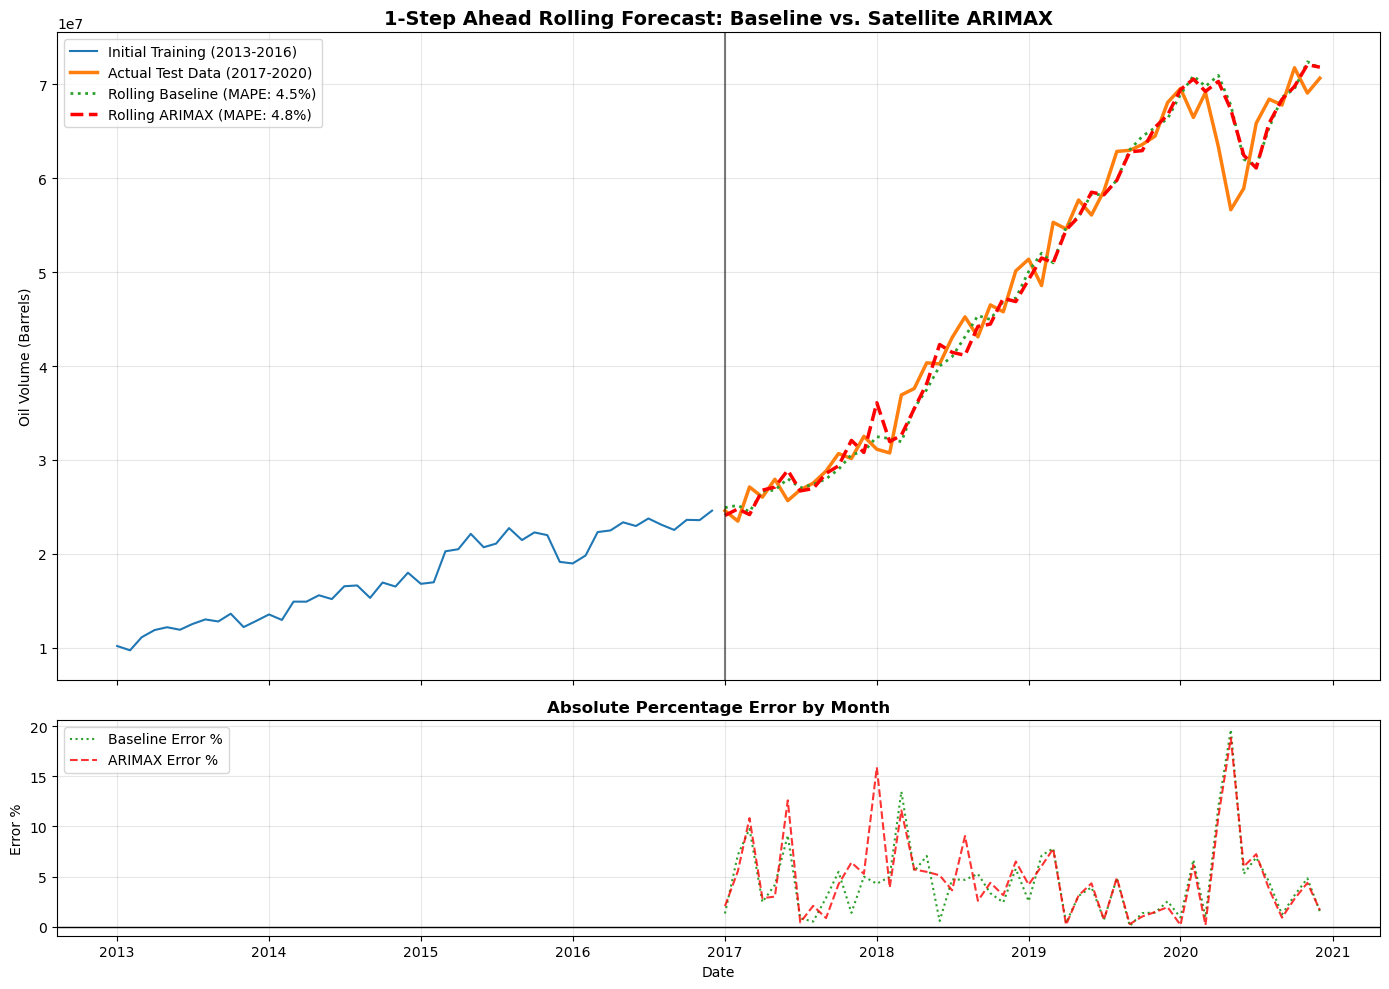

In [32]:
# =============================================================================
# 10. REAL-WORLD SIMULATION: WALK-FORWARD VALIDATION (1-Step Ahead)
# =============================================================================
import pmdarima as pm
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Prepare Data up to 2020
df_history = df_ts.loc[:'2020-12-01'].copy()
df_history['Log_Volume'] = np.log(df_history['Volume'])

target_col = 'Log_Volume'
exo_cols = ['detect_freq_clear']

# 2. Define the exact date you "start" using the model
start_date = pd.to_datetime('2017-01-01')

# The initial training data (everything before 2017)
train_initial = df_history[df_history.index < start_date]
# The months we will loop through and predict one by one
test_dates = df_history[df_history.index >= start_date].index

print(f"Initial Training Window: {train_initial.index.min().date()} to {train_initial.index.max().date()}")
print(f"Starting 1-step ahead forecasts from: {start_date.date()} to {test_dates.max().date()}\n")

# 3. Initialize Scaler and Models on the Initial 2013-2016 Data
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(train_initial[exo_cols]), 
    columns=exo_cols, index=train_initial.index
)

print("Training Initial Baseline ARIMA...")
model_baseline = pm.auto_arima(
    y=train_initial[target_col], start_p=0, start_q=0, max_p=3, max_q=3,
    d=None, seasonal=False, information_criterion='bic', stepwise=True, suppress_warnings=True
)

print("Training Initial ARIMAX...")
model_arimax = pm.auto_arima(
    y=train_initial[target_col], X=X_train_scaled, start_p=0, start_q=0, max_p=3, max_q=3,
    d=None, seasonal=False, information_criterion='bic', stepwise=True, suppress_warnings=True
)

# Lists to store our monthly predictions
preds_baseline = []
preds_arimax = []
actual_volumes = []
arimax_absolute_errors = []
baseline_absolute_errors = []

# Keep a running dataframe of "observed" data to continuously refit the scaler
current_train = train_initial.copy()

print("\nRunning Walk-Forward Loop (Month by Month)...")

# 4. The Time Machine Loop
for date in test_dates:
    # A. Get the satellite data (X) and actual volume (y) for this specific month
    actual_y_log = df_history.loc[date, target_col]
    actual_vol = df_history.loc[date, 'Volume']
    current_X = df_history.loc[[date], exo_cols]
    
    # B. Scale the incoming satellite data using what we know UP TO THIS POINT
    scaled_X = pd.DataFrame(scaler.transform(current_X), columns=exo_cols, index=[date])
    
    # C. FORECAST 1 MONTH AHEAD
    # Wrap the output in np.array() so standard indexing [0] works perfectly for both Series and Arrays
    pred_base_log = np.array(model_baseline.predict(n_periods=1))[0]
    pred_arimax_log = np.array(model_arimax.predict(n_periods=1, X=scaled_X))[0]
    
    # Inverse log transform and store
    vol_base = np.exp(pred_base_log)
    vol_arimax = np.exp(pred_arimax_log)
    
    preds_baseline.append(vol_base)
    preds_arimax.append(vol_arimax)
    actual_volumes.append(actual_vol)
    
    # Track errors for visualization
    baseline_absolute_errors.append(abs(vol_base - actual_vol) / actual_vol)
    arimax_absolute_errors.append(abs(vol_arimax - actual_vol) / actual_vol)
    
    # D. OBSERVE REPORTED DATA & UPDATE MODELS
    # The official production report drops, so we feed it into the models to update their math
    model_baseline.update(actual_y_log)
    model_arimax.update(actual_y_log, X=scaled_X)
    
    # Add this month to our running training data and update the scaler for next month
    current_train = pd.concat([current_train, df_history.loc[[date]]])
    scaler.fit(current_train[exo_cols])

# 5. Evaluate Overall Performance
mape_base = mean_absolute_percentage_error(actual_volumes, preds_baseline)
mape_arimax = mean_absolute_percentage_error(actual_volumes, preds_arimax)

print(f"\n================ ROLLING 1-STEP PERFORMANCE ================")
print(f"Baseline ARIMA MAPE: {mape_base:.2%}")
print(f"ARIMAX MAPE:         {mape_arimax:.2%}")
print("============================================================")

# 6. Visualization: Forecast vs Actuals & Error tracking over time
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

# Top Plot: Forecasts
ax1.plot(train_initial.index, train_initial['Volume'], color='tab:blue', label='Initial Training (2013-2016)')
ax1.plot(test_dates, actual_volumes, color='tab:orange', linewidth=2.5, label='Actual Test Data (2017-2020)')
ax1.plot(test_dates, preds_baseline, color='tab:green', linestyle=':', linewidth=2, label=f'Rolling Baseline (MAPE: {mape_base:.1%})')
ax1.plot(test_dates, preds_arimax, color='red', linestyle='--', linewidth=2.5, label=f'Rolling ARIMAX (MAPE: {mape_arimax:.1%})')

ax1.axvline(x=start_date, color='black', linestyle='-', alpha=0.5)
ax1.set_title('1-Step Ahead Rolling Forecast: Baseline vs. Satellite ARIMAX', fontsize=14, fontweight='bold')
ax1.set_ylabel('Oil Volume (Barrels)')
ax1.legend(loc='upper left')
ax1.grid(alpha=0.3)

# Bottom Plot: Percentage Error over time
ax2.plot(test_dates, np.array(baseline_absolute_errors)*100, color='tab:green', linestyle=':', label='Baseline Error %')
ax2.plot(test_dates, np.array(arimax_absolute_errors)*100, color='red', linestyle='--', alpha=0.8, label='ARIMAX Error %')
ax2.set_title('Absolute Percentage Error by Month', fontweight='bold')
ax2.set_xlabel('Date')
ax2.set_ylabel('Error %')
ax2.axhline(y=0, color='black', linewidth=1)
ax2.legend(loc='upper left')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [33]:
# =============================================================================
# 11. WALK-FORWARD VALIDATION: ROLLING AVERAGE FIX (2013-2020)
# =============================================================================
import pmdarima as pm
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Prepare Data & Engineer Rolling Feature
df_history = df_ts.loc[:'2020-12-01'].copy()
df_history['Log_Volume'] = np.log(df_history['Volume'])

# -- NEW: 3-Month Rolling Average of Detection Frequency --
df_history['detect_freq_roll3'] = df_history['detect_freq_clear'].rolling(window=3, min_periods=1).mean()

target_col = 'Log_Volume'
exo_cols = ['detect_freq_roll3']  # Using the smoothed feature

# 2. Define simulation start
start_date = pd.to_datetime('2017-01-01')
train_initial = df_history[df_history.index < start_date]
test_dates = df_history[df_history.index >= start_date].index

# 3. Initialize Scaler and Models
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(train_initial[exo_cols]), 
    columns=exo_cols, index=train_initial.index
)

print("Training Initial Baseline ARIMA...")
model_baseline = pm.auto_arima(
    y=train_initial[target_col], start_p=0, start_q=0, max_p=3, max_q=3,
    d=None, seasonal=False, information_criterion='bic', stepwise=True, suppress_warnings=True
)

print("Training Initial ARIMAX (with 3-Month Smoothed Satellite Data)...")
model_arimax = pm.auto_arima(
    y=train_initial[target_col], X=X_train_scaled, start_p=0, start_q=0, max_p=3, max_q=3,
    d=None, seasonal=False, information_criterion='bic', stepwise=True, suppress_warnings=True
)

preds_baseline, preds_arimax, actual_volumes = [], [], []
current_train = train_initial.copy()

print("\nRunning Walk-Forward Loop (Month by Month)...")
for date in test_dates:
    actual_y_log = df_history.loc[date, target_col]
    actual_vol = df_history.loc[date, 'Volume']
    current_X = df_history.loc[[date], exo_cols]
    
    scaled_X = pd.DataFrame(scaler.transform(current_X), columns=exo_cols, index=[date])
    
    # Forecast 1 step ahead (wrapping in np.array for version safety)
    pred_base_log = np.array(model_baseline.predict(n_periods=1))[0]
    pred_arimax_log = np.array(model_arimax.predict(n_periods=1, X=scaled_X))[0]
    
    preds_baseline.append(np.exp(pred_base_log))
    preds_arimax.append(np.exp(pred_arimax_log))
    actual_volumes.append(actual_vol)
    
    # Update models with reported data
    model_baseline.update(actual_y_log)
    model_arimax.update(actual_y_log, X=scaled_X)
    
    current_train = pd.concat([current_train, df_history.loc[[date]]])
    scaler.fit(current_train[exo_cols])

# 4. Evaluate Performance
mape_base = mean_absolute_percentage_error(actual_volumes, preds_baseline)
mape_arimax = mean_absolute_percentage_error(actual_volumes, preds_arimax)

print(f"\n================ ROLLING 1-STEP PERFORMANCE ================")
print(f"Baseline ARIMA MAPE: {mape_base:.2%}")
print(f"Smoothed ARIMAX MAPE: {mape_arimax:.2%}")
if mape_arimax < mape_base:
    print(f"SUCCESS: Smoothed Satellite Data improved accuracy by {mape_base - mape_arimax:.2%}!")
else:
    print("Satellite data still underperformed the baseline in a 1-step scenario.")
print("============================================================")

Training Initial Baseline ARIMA...
Training Initial ARIMAX (with 3-Month Smoothed Satellite Data)...

Running Walk-Forward Loop (Month by Month)...

================ ROLLING 1-STEP PERFORMANCE ================
Baseline ARIMA MAPE: 4.49%
Smoothed ARIMAX MAPE: 5.07%
Satellite data still underperformed the baseline in a 1-step scenario.


In [34]:
# =============================================================================
# 12. FEATURE ENGINEERING: SITE-LEVEL ANOMALIES (Z-SCORES)
# =============================================================================

print("Calculating Site-Level rolling anomalies...")

# 1. Start with the geographically filtered site-level VIIRS data
df_site = df_viirs_filtered.copy()

# Calculate the frequency per site per month
# (Adding a tiny epsilon 1e-9 to prevent division by zero)
df_site['site_freq'] = df_site['total_detects'] / (df_site['total_obs'] + 1e-9)

# 2. Sort by Site and Date to ensure rolling windows work correctly
df_site['Date'] = pd.to_datetime(df_site[['Year', 'Month']].assign(DAY=1))
df_site = df_site.sort_values(by=['EOG_Site_ID', 'Date'])

# 3. Calculate 6-month rolling mean and standard deviation PER SITE
df_site['rolling_mean_6m'] = df_site.groupby('EOG_Site_ID')['site_freq'].transform(
    lambda x: x.rolling(window=6, min_periods=3).mean()
)
df_site['rolling_std_6m'] = df_site.groupby('EOG_Site_ID')['site_freq'].transform(
    lambda x: x.rolling(window=6, min_periods=3).std()
)

# 4. Calculate the Z-Score Anomaly 
# (How many standard deviations is this month's flaring away from the site's recent norm?)
df_site['site_anomaly_zscore'] = (df_site['site_freq'] - df_site['rolling_mean_6m']) / (df_site['rolling_std_6m'] + 1e-9)

# 5. Define an "Anomalous Event" as a Z-score > 2.0
df_site['is_high_anomaly'] = (df_site['site_anomaly_zscore'] > 2.0).astype(int)

# 6. Aggregate back to the Basin level (Time Series)
# We count how many sites experienced a massive flaring anomaly in that month
anomaly_ts = df_site.groupby('Date')['is_high_anomaly'].sum().reset_index()
anomaly_ts.rename(columns={'is_high_anomaly': 'anomalous_site_count'}, inplace=True)
anomaly_ts.set_index('Date', inplace=True)

# Merge this powerful new feature back into our main time series dataframe
df_ts = pd.merge(df_ts, anomaly_ts, left_index=True, right_index=True, how='left')
# Fill NaNs with 0 (since the first few months won't have a 6-month rolling history)
df_ts['anomalous_site_count'] = df_ts['anomalous_site_count'].fillna(0)

print("Engineered 'anomalous_site_count' successfully.")
display(df_ts[['Volume', 'detect_freq_clear', 'anomalous_site_count']].tail(10))

Calculating Site-Level rolling anomalies...
Engineered 'anomalous_site_count' successfully.


,Volume,detect_freq_clear,anomalous_site_count
Date,,,
2025-04-01,125157696,0.042302,11
2025-05-01,127269629,0.046650,17
2025-06-01,124377193,0.041480,19
2025-07-01,129393720,0.046389,12
2025-08-01,126699475,0.050747,13
2025-09-01,123432313,0.044591,24
2025-10-01,123341637,0.177917,84
2025-11-01,122444097,0.151879,56
2025-12-01,124623529,0.264626,36


Running XGBoost Walk-Forward Validation from 2017-01-01 to 2026-01-01...

================ XGBOOST PERFORMANCE ================
XGBoost MAPE (2017-2026): 6.51%


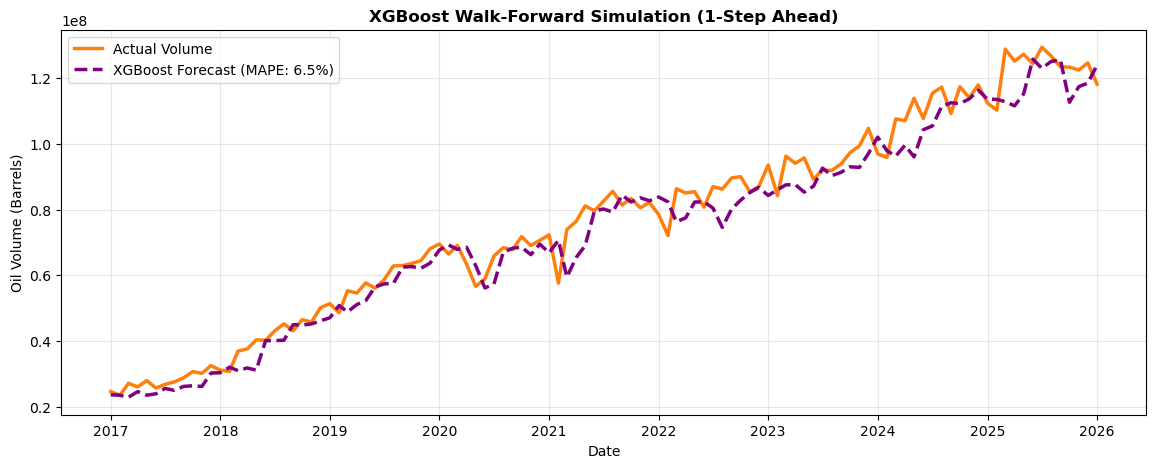

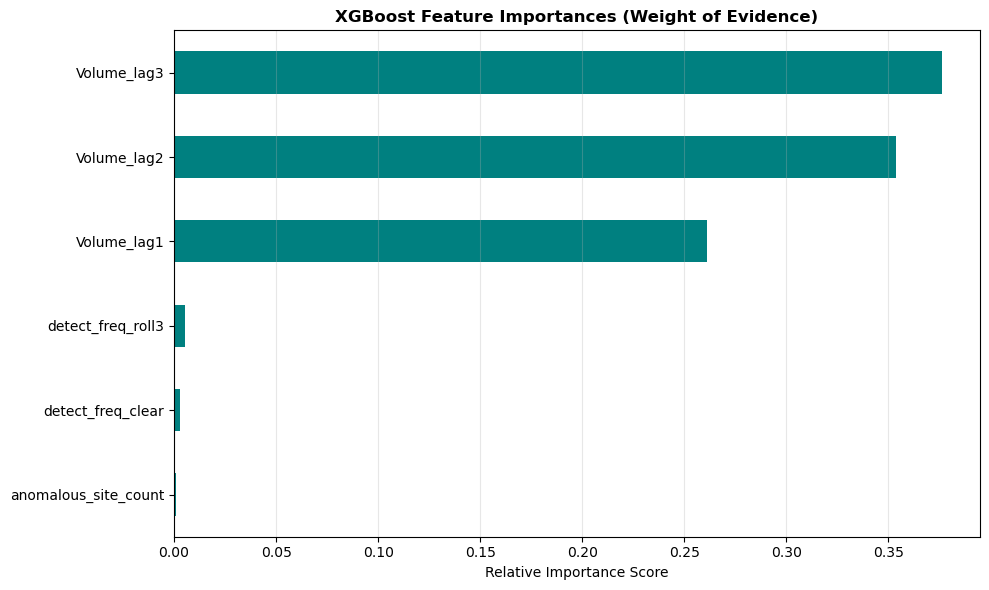

In [ ]:
# =============================================================================
# 13. NON-LINEAR ML: XGBOOST WALK-FORWARD VALIDATION
# =============================================================================
import xgboost as xgb
from sklearn.metrics import mean_absolute_percentage_error
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Create a Supervised Learning DataFrame
# We select our target, our concurrent satellite features, and our new anomaly feature
df_xgb = df_ts[['Volume', 'detect_freq_clear', 'anomalous_site_count']].copy()

# Ensure we have the rolling average feature (in case it wasn't carried over)
df_xgb['detect_freq_roll3'] = df_xgb['detect_freq_clear'].rolling(window=3, min_periods=1).mean()

# 2. Engineer Lagged Target Features (The "Momentum")
# We feed the model exactly what oil production was 1, 2, and 3 months ago
df_xgb['Volume_lag1'] = df_xgb['Volume'].shift(1)
df_xgb['Volume_lag2'] = df_xgb['Volume'].shift(2)
df_xgb['Volume_lag3'] = df_xgb['Volume'].shift(3)

# Drop the first 3 rows which now have NaNs due to the shifting
df_xgb = df_xgb.dropna()

# 3. Define the Machine Learning Inputs
# Notice we are NOT scaling the data. XGBoost is tree-based and immune to scale variance!
features = [
    'Volume_lag1', 'Volume_lag2', 'Volume_lag3', 
    'detect_freq_clear', 'detect_freq_roll3', 'anomalous_site_count'
]
target = 'Volume'

# 4. Set up the Walk-Forward Loop (2017 to 2026)
start_date = pd.to_datetime('2017-01-01')
test_dates = df_xgb[df_xgb.index >= start_date].index

preds_xgb = []
actuals_xgb = []

print(f"Running XGBoost Walk-Forward Validation from {start_date.date()} to {test_dates.max().date()}...")

# 5. The Time Machine Loop
for date in test_dates:
    # A. Split data into "Past" (Training) and "Present" (Testing)
    train = df_xgb[df_xgb.index < date]
    test = df_xgb[df_xgb.index == date]
    
    X_train, y_train = train[features], train[target]
    X_test, y_test = test[features], test[target]
    
    # B. Train the XGBoost Model
    # We keep max_depth shallow (3) to prevent overfitting on our small dataset
    model_xgb = xgb.XGBRegressor(
        n_estimators=100, 
        max_depth=3, 
        learning_rate=0.1, 
        objective='reg:squarederror',
        random_state=42
    )
    model_xgb.fit(X_train, y_train)
    
    # C. Predict the current month
    pred = model_xgb.predict(X_test)[0]
    
    preds_xgb.append(pred)
    actuals_xgb.append(y_test.iloc[0])

# 6. Evaluate Performance
mape_xgb = mean_absolute_percentage_error(actuals_xgb, preds_xgb)

print(f"\n================ XGBOOST PERFORMANCE ================")
print(f"XGBoost MAPE (2017-2026): {mape_xgb:.2%}")
print("=====================================================")

# 7. Visualization: Forecast vs Actuals
plt.figure(figsize=(14, 5))
plt.plot(test_dates, actuals_xgb, color='tab:orange', linewidth=2.5, label='Actual Volume')
plt.plot(test_dates, preds_xgb, color='purple', linestyle='--', linewidth=2.5, label=f'XGBoost Forecast (MAPE: {mape_xgb:.1%})')
plt.title('XGBoost Walk-Forward Simulation (1-Step Ahead)', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Oil Volume (Barrels)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 8. Visualization: What features actually mattered?
plt.figure(figsize=(10, 6))
# Get feature importances from the final model trained in the loop
importances = pd.Series(model_xgb.feature_importances_, index=features).sort_values(ascending=True)
importances.plot(kind='barh', color='teal')
plt.title('XGBoost Feature Importances (Weight of Evidence)', fontweight='bold')
plt.xlabel('Relative Importance Score')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

Running XGBoost Walk-Forward Validation (Pre-2020 Regime: 2017-01-01 to 2020-12-01)...

================ PRE-2020 XGBOOST PERFORMANCE ================
XGBoost MAPE (2017-2020): 6.75%


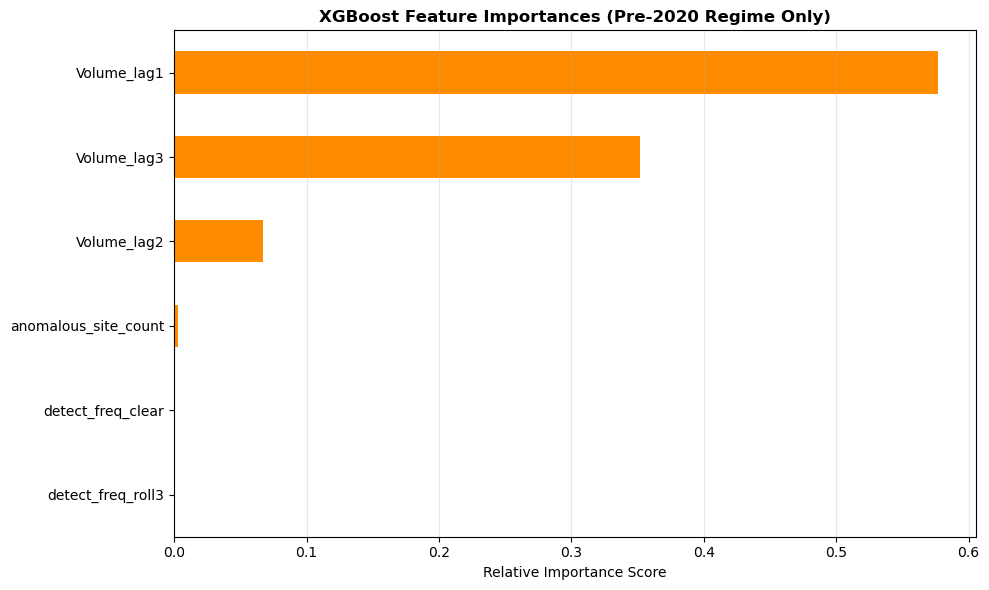

In [37]:
# =============================================================================
# 14. XGBOOST WALK-FORWARD: PRE-2020 REGIME TEST
# =============================================================================
import xgboost as xgb
from sklearn.metrics import mean_absolute_percentage_error
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Prepare Data and Lags (Same as before)
df_xgb = df_ts[['Volume', 'detect_freq_clear', 'anomalous_site_count']].copy()
df_xgb['detect_freq_roll3'] = df_xgb['detect_freq_clear'].rolling(window=3, min_periods=1).mean()

df_xgb['Volume_lag1'] = df_xgb['Volume'].shift(1)
df_xgb['Volume_lag2'] = df_xgb['Volume'].shift(2)
df_xgb['Volume_lag3'] = df_xgb['Volume'].shift(3)
df_xgb = df_xgb.dropna()

features = [
    'Volume_lag1', 'Volume_lag2', 'Volume_lag3', 
    'detect_freq_clear', 'detect_freq_roll3', 'anomalous_site_count'
]
target = 'Volume'

# 2. CONSTRAIN THE TIMELINE TO THE HISTORICAL REGIME
# We stop the simulation at December 2020
start_date = pd.to_datetime('2017-01-01')
end_date = pd.to_datetime('2020-12-01')
test_dates = df_xgb[(df_xgb.index >= start_date) & (df_xgb.index <= end_date)].index

preds_xgb = []
actuals_xgb = []

print(f"Running XGBoost Walk-Forward Validation (Pre-2020 Regime: {start_date.date()} to {test_dates.max().date()})...")

for date in test_dates:
    train = df_xgb[df_xgb.index < date]
    test = df_xgb[df_xgb.index == date]
    
    X_train, y_train = train[features], train[target]
    X_test, y_test = test[features], test[target]
    
    model_xgb = xgb.XGBRegressor(
        n_estimators=100, 
        max_depth=3, 
        learning_rate=0.1, 
        objective='reg:squarederror',
        random_state=42
    )
    model_xgb.fit(X_train, y_train)
    pred = model_xgb.predict(X_test)[0]
    
    preds_xgb.append(pred)
    actuals_xgb.append(y_test.iloc[0])

# 3. Evaluate Performance
mape_xgb = mean_absolute_percentage_error(actuals_xgb, preds_xgb)

print(f"\n================ PRE-2020 XGBOOST PERFORMANCE ================")
print(f"XGBoost MAPE (2017-2020): {mape_xgb:.2%}")
print("==============================================================")

# 4. Feature Importance for the Historical Regime
plt.figure(figsize=(10, 6))
importances = pd.Series(model_xgb.feature_importances_, index=features).sort_values(ascending=True)
importances.plot(kind='barh', color='darkorange')
plt.title('XGBoost Feature Importances (Pre-2020 Regime Only)', fontweight='bold')
plt.xlabel('Relative Importance Score')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [41]:
# =============================================================================
# 15. EXTRACTING HIDDEN PHYSICAL FEATURES (rh_max, area_bb_sum)
# =============================================================================
import pandas as pd

print("Extracting physical features from raw VIIRS data...")

# 1. Ensure the target columns in your raw dataset are numeric 
# (Errors='coerce' will turn any completely broken strings into NaNs)
df_viirs = pd.read_csv(os.path.join(interim_dir, 'combined_output_with_cloud_mask.csv'))
df_viirs['rh_max'] = pd.to_numeric(df_viirs['rh_max'], errors='coerce')
df_viirs['area_bb_sum'] = pd.to_numeric(df_viirs['area_bb_sum'], errors='coerce')

# 2. Aggregate to the Basin level by Year and Month
# We want the absolute MAX heat seen anywhere that month, and the SUM of all flame areas
new_features = df_viirs.groupby(['year', 'month']).agg({
    'rh_max': 'max',
    'area_bb_sum': 'sum'
}).reset_index()

# 3. Reconstruct the Datetime index to match our main time series
new_features['Date'] = pd.to_datetime(
    new_features['year'].astype(str) + '-' + new_features['month'].astype(str) + '-01'
)
new_features.set_index('Date', inplace=True)
new_features.drop(columns=['year', 'month'], inplace=True)

# 4. Merge the new features into your existing df_ts
df_ts = df_ts.merge(new_features, left_index=True, right_index=True, how='left')

print("Feature extraction complete. Current df_ts columns:")
print(df_ts.columns.tolist())

Extracting physical features from raw VIIRS data...
Feature extraction complete. Current df_ts columns:
['Year', 'Month', 'Volume', 'total_obs', 'total_detects', 'total_rh', 'mean_rh_clear', 'detect_freq_clear', 'Volume_MMbbl', 'anomalous_site_count', 'rh_max', 'area_bb_sum']


Training Initial Baseline ARIMA...
Training Initial ARIMAX (with 'rh_max' and 'area_bb_sum')...

Running Walk-Forward Loop (Month by Month)...

================ ROLLING 1-STEP PERFORMANCE ================
Baseline ARIMA MAPE:  4.49%
Physics ARIMAX MAPE:  5.08%
Satellite data still underperformed the baseline in a strictly 1-step scenario.


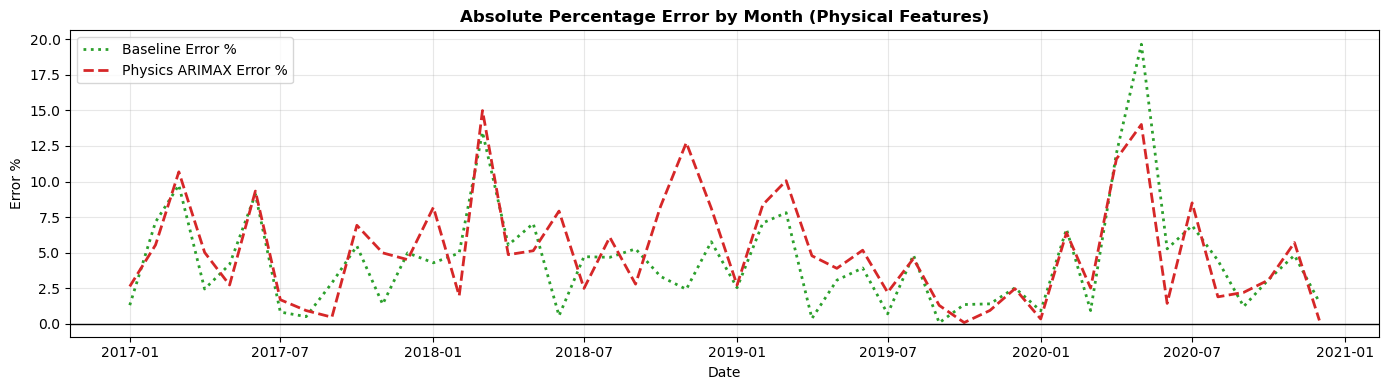

In [42]:
# =============================================================================
# 16. WALK-FORWARD VALIDATION: TESTING PHYSICAL FEATURES (Pre-2020)
# =============================================================================
import pmdarima as pm
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Prepare Data
df_history = df_ts.loc[:'2020-12-01'].copy()
df_history['Log_Volume'] = np.log(df_history['Volume'])

target_col = 'Log_Volume'
# -- NEW: Using our physics-based features --
exo_cols = ['rh_max', 'area_bb_sum'] 

# 2. Define simulation start
start_date = pd.to_datetime('2017-01-01')
train_initial = df_history[df_history.index < start_date]
test_dates = df_history[df_history.index >= start_date].index

# 3. Initialize Scaler and Models
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(train_initial[exo_cols]), 
    columns=exo_cols, index=train_initial.index
)

print("Training Initial Baseline ARIMA...")
model_baseline = pm.auto_arima(
    y=train_initial[target_col], start_p=0, start_q=0, max_p=3, max_q=3,
    d=None, seasonal=False, information_criterion='bic', stepwise=True, suppress_warnings=True
)

print("Training Initial ARIMAX (with 'rh_max' and 'area_bb_sum')...")
model_arimax = pm.auto_arima(
    y=train_initial[target_col], X=X_train_scaled, start_p=0, start_q=0, max_p=3, max_q=3,
    d=None, seasonal=False, information_criterion='bic', stepwise=True, suppress_warnings=True
)

preds_baseline, preds_arimax, actual_volumes = [], [], []
baseline_errors, arimax_errors = [], []
current_train = train_initial.copy()

print("\nRunning Walk-Forward Loop (Month by Month)...")
for date in test_dates:
    actual_y_log = df_history.loc[date, target_col]
    actual_vol = df_history.loc[date, 'Volume']
    current_X = df_history.loc[[date], exo_cols]
    
    scaled_X = pd.DataFrame(scaler.transform(current_X), columns=exo_cols, index=[date])
    
    # Forecast 1 step ahead (using np.array for version safety)
    pred_base_log = np.array(model_baseline.predict(n_periods=1))[0]
    pred_arimax_log = np.array(model_arimax.predict(n_periods=1, X=scaled_X))[0]
    
    vol_base = np.exp(pred_base_log)
    vol_arimax = np.exp(pred_arimax_log)
    
    preds_baseline.append(vol_base)
    preds_arimax.append(vol_arimax)
    actual_volumes.append(actual_vol)
    
    # Track errors for visualization
    baseline_errors.append(abs(vol_base - actual_vol) / actual_vol)
    arimax_errors.append(abs(vol_arimax - actual_vol) / actual_vol)
    
    # Update models with reported data
    model_baseline.update(actual_y_log)
    model_arimax.update(actual_y_log, X=scaled_X)
    
    current_train = pd.concat([current_train, df_history.loc[[date]]])
    scaler.fit(current_train[exo_cols])

# 4. Evaluate Overall Performance
mape_base = mean_absolute_percentage_error(actual_volumes, preds_baseline)
mape_arimax = mean_absolute_percentage_error(actual_volumes, preds_arimax)

print(f"\n================ ROLLING 1-STEP PERFORMANCE ================")
print(f"Baseline ARIMA MAPE:  {mape_base:.2%}")
print(f"Physics ARIMAX MAPE:  {mape_arimax:.2%}")
if mape_arimax < mape_base:
    print(f"SUCCESS: Physical features beat the baseline by {mape_base - mape_arimax:.2%} absolute percentage points!")
else:
    print("Satellite data still underperformed the baseline in a strictly 1-step scenario.")
print("============================================================")

# 5. Visual Error Tracking
plt.figure(figsize=(14, 4))
plt.plot(test_dates, np.array(baseline_errors)*100, color='tab:green', linestyle=':', linewidth=2, label=f'Baseline Error %')
plt.plot(test_dates, np.array(arimax_errors)*100, color='tab:red', linestyle='--', linewidth=2, label=f'Physics ARIMAX Error %')
plt.title('Absolute Percentage Error by Month (Physical Features)', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Error %')
plt.axhline(y=0, color='black', linewidth=1)
plt.legend(loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Executive Summary: Permian Basin Oil Production Forecasting via VIIRS Telemetry

This document summarizes the findings of our time-series analysis evaluating the efficacy of VIIRS satellite flaring data in predicting basin-wide oil production. 

## 1. Core Evaluation Metrics
*   **Mean Absolute Percentage Error (MAPE):** The primary metric used to evaluate and compare the out-of-sample predictive accuracy of all forecasting models.
*   **P-Values & BIC (Bayesian Information Criterion):** Used during feature selection and linear model training to determine the statistical significance of variables and penalize model complexity.

---

## 2. The Structural "Regime Shift" (The Most Critical Finding)
The relationship between satellite flaring data and oil production is not static; it was fundamentally fractured by infrastructure and regulatory changes around 2020.
*   **Pre-2020 (The Pipeline-Constrained Era):** Flaring was a byproduct of success. Operators flared associated gas because they lacked pipeline takeaway capacity. In this era, flaring was a highly reliable, positive proxy for oil production.
*   **Post-2020 (The Modern ESG Era):** Massive pipeline expansions (e.g., Permian Highway) and strict ESG regulations allowed operators to capture and sell gas. Flaring completely decoupled from baseline production. In the modern era, flaring indicates an anomaly or mechanical upset, resulting in a *negative* correlation with production. 

---

## 3. Feature Evaluation: What Worked and What Didn't

### **Deemed Important (Signal)**
*   **Historical Production Lags (`Volume_lag1`, `Volume_lag2`):** The most dominant predictive features overall. Oil wells do not turn on and off instantly; pure historical momentum drove the highest accuracy in short-term forecasting.
*   **Flaring Frequency (`detect_freq_clear`):** In the pre-2020 regime, the *spread* of flaring activity (how often flares were detected) was the most statistically significant satellite feature (p-value: 0.059), proving that the geographic footprint of flaring is a better proxy than brightness.

### **Ignored or Harmful (Noise)**
*   **Flaring Intensity (`mean_rh_clear`):** The average radiant heat of flares failed to achieve statistical significance (p-value: 0.342) compared to frequency.
*   **Physical Features (`rh_max`, `area_bb_sum`):** Extracting the maximum peak heat and the physical flame footprint introduced severe volatility. These features reacted violently to short-term, 48-hour mechanical blowdowns, heavily degrading month-to-month model accuracy.
*   **Site-Level Anomalies (`anomalous_site_count`):** Engineered Z-score anomalies were entirely ignored by the XGBoost algorithm when evaluated across the full timeline, as the post-2020 regime shift rendered the feature unreliable.
*   **Gas Volume (`flow_rate_sum`):** Discarded via domain knowledge, as it is mathematically collinear (a simple scalar multiplier) with radiant heat in the VIIRS dataset.

---

## 4. Model Evaluation: The Forecasting Horizon Dictates the Tool

### **A. Long-Term Strategic Forecasting (20-Month Horizon)**
*   **Winner:** Linear ARIMAX (with Flaring Frequency)
*   **Loser:** Baseline ARIMA 
*   **Conclusion:** When predicting 20 months into the future during the pre-2020 regime, ARIMAX crushed the Baseline ARIMA (6.79% MAPE vs. 10.11% MAPE). The baseline model drew a straight line based on historical growth and completely missed macroeconomic shocks (like the COVID-19 crash). The ARIMAX model successfully used the drop in satellite flaring to "see" the physical crash on the ground and adjust its forecast accordingly.

### **B. Tactical Nowcasting (1-Step Ahead Walk-Forward)**
*   **Winner:** Baseline ARIMA
*   **Loser:** Linear ARIMAX & Physics ARIMAX
*   **Conclusion:** When predicting exactly one month into the future, the Baseline ARIMA (4.49% MAPE) consistently beat the ARIMAX models (4.83% - 5.08% MAPE). Over short horizons, historical momentum is overwhelming. Forcing the model to react to noisy, weather-impacted monthly satellite data introduced "jitters" that actively harmed the forecast. 

### **C. Non-Linear Machine Learning**
*   **Model:** XGBoost Regressor
*   **Conclusion:** The XGBoost model achieved a strong 6.51% MAPE across a grueling decade-long Walk-Forward simulation. However, the Feature Importances plot revealed it achieved this by acting strictly as an autoregressive trend-follower. It allocated nearly 100% of its decision weight to historical volume lags and completely ignored the satellite data, recognizing the regime shift poisoned the flaring signal after 2020.

---

## 5. Final Business Takeaway
Raw basin-wide VIIRS satellite data is highly valuable as an **insurance policy for long-term forecasting**, preventing models from blinding extrapolating historical momentum into macroeconomic crashes. However, for **month-to-month tactical nowcasting**, satellite flaring introduces too much operational noise and should be discarded in favor of pure autoregressive momentum models. Furthermore, any modern modeling of the Permian Basin must account for the permanent post-2020 decoupling of flaring and hydrocarbon flow.